In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Objectives:
1. To understand customers making purchases from different work communities.
2. Finding cutomers preferred language in order to make it convenient for them to use company's website.
3. Preferred credit card service providers in order to provide attarctive deals on purchase.
4. Analysing the preffered hour of purchase to ensure efficiency.
5. Finding preferred website used by customers to  advertise different company products and services.

In [2]:
df=pd.read_csv("/kaggle/input/ecommerce-purchases/Ecommerce Purchases")
df

,Address,Lot,AM or PM,Browser Info,Company,Credit Card,CC Exp Date,CC Security Code,CC Provider,Email,Job,IP Address,Language,Purchase Price
0,"16629 Pace Camp Apt. 448\nAlexisborough, NE 77...",46 in,PM,Opera/9.56.(X11; Linux x86_64; sl-SI) Presto/2...,Martinez-Herman,6011929061123406,02/20,900,JCB 16 digit,pdunlap@yahoo.com,"Scientist, product/process development",149.146.147.205,el,98.14
1,"9374 Jasmine Spurs Suite 508\nSouth John, TN 8...",28 rn,PM,Opera/8.93.(Windows 98; Win 9x 4.90; en-US) Pr...,"Fletcher, Richards and Whitaker",3337758169645356,11/18,561,Mastercard,anthony41@reed.com,Drilling engineer,15.160.41.51,fr,70.73
2,Unit 0065 Box 5052\nDPO AP 27450,94 vE,PM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Simpson, Williams and Pham",675957666125,08/19,699,JCB 16 digit,amymiller@morales-harrison.com,Customer service manager,132.207.160.22,de,0.95
3,"7780 Julia Fords\nNew Stacy, WA 45798",36 vm,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_0 ...,"Williams, Marshall and Buchanan",6011578504430710,02/24,384,Discover,brent16@olson-robinson.info,Drilling engineer,30.250.74.19,es,78.04
4,"23012 Munoz Drive Suite 337\nNew Cynthia, TX 5...",20 IE,AM,Opera/9.58.(X11; Linux x86_64; it-IT) Presto/2...,"Brown, Watson and Andrews",6011456623207998,10/25,678,Diners Club / Carte Blanche,christopherwright@gmail.com,Fine artist,24.140.33.94,es,77.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,"966 Castaneda Locks\nWest Juliafurt, CO 96415",92 XI,PM,Mozilla/5.0 (Windows NT 5.1) AppleWebKit/5352 ...,Randall-Sloan,342945015358701,03/22,838,JCB 15 digit,iscott@wade-garner.com,Printmaker,29.73.197.114,it,82.21
9996,"832 Curtis Dam Suite 785\nNorth Edwardburgh, T...",41 JY,AM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Hale, Collins and Wilson",210033169205009,07/25,207,JCB 16 digit,mary85@hotmail.com,Energy engineer,121.133.168.51,pt,25.63
9997,Unit 4434 Box 6343\nDPO AE 28026-0283,74 Zh,AM,Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_7...,Anderson Ltd,6011539787356311,05/21,1,VISA 16 digit,tyler16@gmail.com,Veterinary surgeon,156.210.0.254,el,83.98
9998,"0096 English Rest\nRoystad, IA 12457",74 cL,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_8;...,Cook Inc,180003348082930,11/17,987,American Express,elizabethmoore@reid.net,Local government officer,55.78.26.143,es,38.84


# Understanding the data:

# 1. Display first 10 rows of the data

In [3]:
df.head(10)

,Address,Lot,AM or PM,Browser Info,Company,Credit Card,CC Exp Date,CC Security Code,CC Provider,Email,Job,IP Address,Language,Purchase Price
0,"16629 Pace Camp Apt. 448\nAlexisborough, NE 77...",46 in,PM,Opera/9.56.(X11; Linux x86_64; sl-SI) Presto/2...,Martinez-Herman,6011929061123406,02/20,900,JCB 16 digit,pdunlap@yahoo.com,"Scientist, product/process development",149.146.147.205,el,98.14
1,"9374 Jasmine Spurs Suite 508\nSouth John, TN 8...",28 rn,PM,Opera/8.93.(Windows 98; Win 9x 4.90; en-US) Pr...,"Fletcher, Richards and Whitaker",3337758169645356,11/18,561,Mastercard,anthony41@reed.com,Drilling engineer,15.160.41.51,fr,70.73
2,Unit 0065 Box 5052\nDPO AP 27450,94 vE,PM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Simpson, Williams and Pham",675957666125,08/19,699,JCB 16 digit,amymiller@morales-harrison.com,Customer service manager,132.207.160.22,de,0.95
3,"7780 Julia Fords\nNew Stacy, WA 45798",36 vm,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_0 ...,"Williams, Marshall and Buchanan",6011578504430710,02/24,384,Discover,brent16@olson-robinson.info,Drilling engineer,30.250.74.19,es,78.04
4,"23012 Munoz Drive Suite 337\nNew Cynthia, TX 5...",20 IE,AM,Opera/9.58.(X11; Linux x86_64; it-IT) Presto/2...,"Brown, Watson and Andrews",6011456623207998,10/25,678,Diners Club / Carte Blanche,christopherwright@gmail.com,Fine artist,24.140.33.94,es,77.82
5,"7502 Powell Mission Apt. 768\nTravisland, VA 3...",21 XT,PM,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_8_5...,Silva-Anderson,30246185196287,07/25,7169,Discover,ynguyen@gmail.com,Fish farm manager,55.96.152.147,ru,25.15
6,"93971 Conway Causeway\nAndersonburgh, AZ 75107",96 Xt,AM,Mozilla/5.0 (compatible; MSIE 7.0; Windows NT ...,Gibson and Sons,6011398782655569,07/24,714,VISA 16 digit,olivia04@yahoo.com,Dancer,127.252.144.18,de,88.56
7,"260 Rachel Plains Suite 366\nCastroberg, WV 24...",96 pG,PM,Mozilla/5.0 (X11; Linux i686) AppleWebKit/5350...,Marshall-Collins,561252141909,06/25,256,VISA 13 digit,phillip48@parks.info,Event organiser,224.247.97.150,pt,44.25
8,"2129 Dylan Burg\nNew Michelle, ME 28650",45 JN,PM,Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_7...,Galloway and Sons,180041795790001,04/24,899,JCB 16 digit,kdavis@rasmussen.com,Financial manager,146.234.201.229,ru,59.54
9,"3795 Dawson Extensions\nLake Tinafort, ID 88739",15 Ug,AM,Mozilla/5.0 (X11; Linux i686; rv:1.9.7.20) Gec...,"Rivera, Buchanan and Ramirez",4396283918371,01/17,931,American Express,qcoleman@hunt-huerta.com,Forensic scientist,236.198.199.8,zh,95.63


# 2. Display bottom 10 rows of the data

In [4]:
df.tail(10)

,Address,Lot,AM or PM,Browser Info,Company,Credit Card,CC Exp Date,CC Security Code,CC Provider,Email,Job,IP Address,Language,Purchase Price
9990,"75731 Molly Springs\nWest Danielle, VT 96934-5102",93 ty,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_7_4;...,"Pace, Vazquez and Richards",869968197049750,04/24,877,JCB 15 digit,andersonmichael@sherman.biz,Early years teacher,54.170.3.185,ru,18.35
9991,"PSC 8165, Box 8498\nAPO AP 60327-0346",50 dA,AM,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Snyder Inc,4221582137197481,02/24,969,Voyager,kking@wise-liu.com,IT sales professional,254.25.31.156,el,25.93
9992,"885 Allen Mountains Apt. 230\nWallhaven, LA 16995",40 vH,PM,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_6_5) A...,Wells Ltd,4664825258997302,10/20,431,Discover,bberry@wright.net,Set designer,174.173.51.32,de,67.96
9993,"7555 Larson Locks Suite 229\nEllisburgh, MA 34...",72 jg,PM,Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_8...,Colon and Sons,30025560104631,10/25,629,Maestro,chelseawilliams@lopez.biz,"Designer, exhibition/display",177.46.82.128,el,65.61
9994,"6276 Rojas Hollow\nLake Louis, WY 56410-7837",93 Ex,PM,Opera/9.68.(X11; Linux x86_64; sl-SI) Presto/2...,Ritter-Smith,3112186784121077,01/25,1823,Maestro,iroberts@gmail.com,"Education officer, museum",242.44.112.18,zh,31.85
9995,"966 Castaneda Locks\nWest Juliafurt, CO 96415",92 XI,PM,Mozilla/5.0 (Windows NT 5.1) AppleWebKit/5352 ...,Randall-Sloan,342945015358701,03/22,838,JCB 15 digit,iscott@wade-garner.com,Printmaker,29.73.197.114,it,82.21
9996,"832 Curtis Dam Suite 785\nNorth Edwardburgh, T...",41 JY,AM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Hale, Collins and Wilson",210033169205009,07/25,207,JCB 16 digit,mary85@hotmail.com,Energy engineer,121.133.168.51,pt,25.63
9997,Unit 4434 Box 6343\nDPO AE 28026-0283,74 Zh,AM,Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_7...,Anderson Ltd,6011539787356311,05/21,1,VISA 16 digit,tyler16@gmail.com,Veterinary surgeon,156.210.0.254,el,83.98
9998,"0096 English Rest\nRoystad, IA 12457",74 cL,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_8;...,Cook Inc,180003348082930,11/17,987,American Express,elizabethmoore@reid.net,Local government officer,55.78.26.143,es,38.84
9999,"40674 Barrett Stravenue\nGrimesville, WI 79682",64 Hr,AM,Mozilla/5.0 (X11; Linux i686; rv:1.9.5.20) Gec...,Greene Inc,4139972901927273,02/19,302,JCB 15 digit,rachelford@vaughn.com,"Embryologist, clinical",176.119.198.199,el,67.59


# 3. Column names and their datatypes

In [5]:
df.columns

Index(['Address', 'Lot', 'AM or PM', 'Browser Info', 'Company', 'Credit Card',
       'CC Exp Date', 'CC Security Code', 'CC Provider', 'Email', 'Job',
       'IP Address', 'Language', 'Purchase Price'],
      dtype='object')

In [6]:
df.dtypes

Address              object
Lot                  object
AM or PM             object
Browser Info         object
Company              object
Credit Card           int64
CC Exp Date          object
CC Security Code      int64
CC Provider          object
Email                object
Job                  object
IP Address           object
Language             object
Purchase Price      float64
dtype: object

# 4. check for null values:

In [7]:
df.isna().sum()

Address             0
Lot                 0
AM or PM            0
Browser Info        0
Company             0
Credit Card         0
CC Exp Date         0
CC Security Code    0
CC Provider         0
Email               0
Job                 0
IP Address          0
Language            0
Purchase Price      0
dtype: int64

# 5. No. of rows and columns:

In [8]:
df.shape

(10000, 14)

In [9]:
rows=df.shape[0]
cols=df.shape[1]
print(f'Total No. of Rows: {rows}, and columns: {cols}')

Total No. of Rows: 10000, and columns: 14


# 6. Highest and lowest Purchase prices:

In [10]:
df.columns

Index(['Address', 'Lot', 'AM or PM', 'Browser Info', 'Company', 'Credit Card',
       'CC Exp Date', 'CC Security Code', 'CC Provider', 'Email', 'Job',
       'IP Address', 'Language', 'Purchase Price'],
      dtype='object')

In [11]:
df['Purchase Price'].max()

99.99

In [12]:
df['Purchase Price'].min()

0.0

In [13]:
df["AM or PM"].value_counts()

PM    5068
AM    4932
Name: AM or PM, dtype: int64

In [14]:
g=df[df["AM or PM"]=="AM"].value_counts()
g.dtype

dtype('int64')

# 7. Average purchase price:

In [15]:
df['Purchase Price'].mean()

50.347302

# 8. No. of customers that speak French:

In [16]:
df.columns

Index(['Address', 'Lot', 'AM or PM', 'Browser Info', 'Company', 'Credit Card',
       'CC Exp Date', 'CC Security Code', 'CC Provider', 'Email', 'Job',
       'IP Address', 'Language', 'Purchase Price'],
      dtype='object')

In [17]:
df.Language #fr = French

0       el
1       fr
2       de
3       es
4       es
        ..
9995    it
9996    pt
9997    el
9998    es
9999    el
Name: Language, Length: 10000, dtype: object

In [18]:
#no. of customers that speak French
df[df["Language"]=="fr"].value_counts().sum() 

1097

# 9. Customers who're engineers:

In [19]:
df.columns

Index(['Address', 'Lot', 'AM or PM', 'Browser Info', 'Company', 'Credit Card',
       'CC Exp Date', 'CC Security Code', 'CC Provider', 'Email', 'Job',
       'IP Address', 'Language', 'Purchase Price'],
      dtype='object')

In [20]:
df.Job

0       Scientist, product/process development
1                            Drilling engineer
2                     Customer service manager
3                            Drilling engineer
4                                  Fine artist
                         ...                  
9995                                Printmaker
9996                           Energy engineer
9997                        Veterinary surgeon
9998                  Local government officer
9999                    Embryologist, clinical
Name: Job, Length: 10000, dtype: object

In [21]:
#df1 contains customer information that are engineers by profession
df1=df[df["Job"].str.contains("engineer", case=False)] 
df1

,Address,Lot,AM or PM,Browser Info,Company,Credit Card,CC Exp Date,CC Security Code,CC Provider,Email,Job,IP Address,Language,Purchase Price
1,"9374 Jasmine Spurs Suite 508\nSouth John, TN 8...",28 rn,PM,Opera/8.93.(Windows 98; Win 9x 4.90; en-US) Pr...,"Fletcher, Richards and Whitaker",3337758169645356,11/18,561,Mastercard,anthony41@reed.com,Drilling engineer,15.160.41.51,fr,70.73
3,"7780 Julia Fords\nNew Stacy, WA 45798",36 vm,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_0 ...,"Williams, Marshall and Buchanan",6011578504430710,02/24,384,Discover,brent16@olson-robinson.info,Drilling engineer,30.250.74.19,es,78.04
50,"41159 Michael Centers\nAdamsfort, RI 37108-6674",46 Ce,PM,Mozilla/5.0 (Windows 98; Win 9x 4.90; sl-SI; r...,"Wright, Williams and Mendez",4008586485908075,05/19,945,JCB 16 digit,susanvalentine@obrien.org,Mechanical engineer,213.203.143.215,de,36.85
55,"27635 Maureen Bypass Apt. 883\nSandraview, SD ...",59 LJ,AM,Mozilla/5.0 (iPod; U; CPU iPhone OS 3_3 like M...,Sims-Lyons,3158113629128344,09/19,857,VISA 16 digit,adkinsarthur@yahoo.com,"Engineer, broadcasting (operations)",227.235.89.210,pt,48.74
60,"7126 Katherine Squares\nPerkinsview, CO 97299-...",63 qu,AM,Opera/8.68.(X11; Linux x86_64; en-US) Presto/2...,Marshall-Fernandez,349767747049645,05/20,672,JCB 15 digit,sweeneyhannah@jones.biz,"Engineer, agricultural",197.144.142.102,de,20.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9948,"95544 Johnson Isle Suite 939\nMichaelberg, RI ...",91 bW,AM,Opera/8.36.(X11; Linux x86_64; sl-SI) Presto/2...,Fox-Peterson,4762924304307,03/17,567,Mastercard,haleybenjamin@gmail.com,Structural engineer,120.36.140.58,en,71.89
9952,"9991 Vaughn Hills\nRacheltown, PA 55409",36 KC,PM,Mozilla/5.0 (X11; Linux i686; rv:1.9.5.20) Gec...,"Ward, Smith and Castillo",6011679271321726,09/19,964,Voyager,jonesjennifer@olson.com,"Engineer, energy",116.228.12.42,es,39.63
9970,"0060 Keith Stream\nWestport, CO 47097",11 nt,PM,Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_8...,"Carpenter, Good and Hart",6011485664704662,07/19,543,Discover,rangelbrian@hotmail.com,Electrical engineer,242.8.85.205,en,17.76
9977,"02182 Keith Expressway\nEast Shannon, CT 20578...",34 RL,AM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Deleon, Jacobson and Benton",4186094003664688,06/21,397,JCB 16 digit,daltoncarter@yahoo.com,Biomedical engineer,146.238.118.2,fr,94.93


In [22]:
#types of engineers
unique_values=df1["Job"].unique()
unique_values

array(['Drilling engineer', 'Mechanical engineer',
       'Engineer, broadcasting (operations)', 'Engineer, agricultural',
       'Engineer, civil (consulting)', 'Engineer, materials',
       'Engineer, land', 'Engineer, water', 'Technical sales engineer',
       'Engineer, aeronautical', 'Engineering geologist',
       'Engineer, chemical', 'Engineer, building services',
       'Energy engineer', 'Water engineer', 'Software engineer',
       'Engineer, civil (contracting)', 'Structural engineer',
       'Mining engineer', 'Engineer, energy',
       'Manufacturing systems engineer',
       'Control and instrumentation engineer',
       'Consulting civil engineer', 'Engineer, structural',
       'Site engineer', 'Engineer, maintenance (IT)',
       'Petroleum engineer', 'Engineer, maintenance',
       'Communications engineer', 'Civil engineer, consulting',
       'Engineer, production', 'Engineer, communications',
       'Engineer, drilling', 'Engineer, control and instrumentation',
  

# 10. Find email of a person with IP address as : "146.238.118.2"

In [23]:
df["IP Address"]

0       149.146.147.205
1          15.160.41.51
2        132.207.160.22
3          30.250.74.19
4          24.140.33.94
             ...       
9995      29.73.197.114
9996     121.133.168.51
9997      156.210.0.254
9998       55.78.26.143
9999    176.119.198.199
Name: IP Address, Length: 10000, dtype: object

In [24]:
df[df["IP Address"]=="146.238.118.2"]["Email"]

9977    daltoncarter@yahoo.com
Name: Email, dtype: object

# 11. Customers who have used Mastercards as their credit card service provider and made payments above $50 : 

In [25]:
df.columns

Index(['Address', 'Lot', 'AM or PM', 'Browser Info', 'Company', 'Credit Card',
       'CC Exp Date', 'CC Security Code', 'CC Provider', 'Email', 'Job',
       'IP Address', 'Language', 'Purchase Price'],
      dtype='object')

In [26]:
df["CC Provider"]

0                      JCB 16 digit
1                        Mastercard
2                      JCB 16 digit
3                          Discover
4       Diners Club / Carte Blanche
                   ...             
9995                   JCB 15 digit
9996                   JCB 16 digit
9997                  VISA 16 digit
9998               American Express
9999                   JCB 15 digit
Name: CC Provider, Length: 10000, dtype: object

In [27]:
df[(df["CC Provider"]=="Mastercard")&(df["Purchase Price"]>=50)]

,Address,Lot,AM or PM,Browser Info,Company,Credit Card,CC Exp Date,CC Security Code,CC Provider,Email,Job,IP Address,Language,Purchase Price
1,"9374 Jasmine Spurs Suite 508\nSouth John, TN 8...",28 rn,PM,Opera/8.93.(Windows 98; Win 9x 4.90; en-US) Pr...,"Fletcher, Richards and Whitaker",3337758169645356,11/18,561,Mastercard,anthony41@reed.com,Drilling engineer,15.160.41.51,fr,70.73
18,"461 Christopher Square\nWest Michaelchester, C...",17 SB,PM,Mozilla/5.0 (X11; Linux i686; rv:1.9.6.20) Gec...,"Beard, Abbott and Pena",6011350184276270,12/22,767,Mastercard,hannah63@yahoo.com,Photographer,73.250.176.201,el,70.15
31,USNS Alvarado\nFPO AA 27052-1231,26 Lh,PM,Opera/8.84.(X11; Linux i686; sl-SI) Presto/2.9...,Nicholson Group,4614997834548,03/22,909,Mastercard,ashley12@hotmail.com,Sales executive,94.176.142.201,en,94.14
35,"93392 Webb Gardens Apt. 220\nLaurabury, AR 999...",37 om,AM,Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_7...,Mora Ltd,6011049630969815,09/16,367,Mastercard,hgonzalez@mcdowell.com,"Lecturer, further education",216.23.95.40,zh,97.46
90,"431 Bowen Lights\nFergusonborough, MH 01362",31 tG,AM,Mozilla/5.0 (Windows NT 5.2; it-IT; rv:1.9.1.2...,Copeland-Lee,639032576097,06/18,868,Mastercard,nrogers@brown.com,"Teacher, English as a foreign language",153.188.13.203,es,78.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9941,"43757 Brown Lodge\nValerieberg, PR 88518",68 DG,AM,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,"Jones, Williams and Dunn",6011508474487291,04/26,906,Mastercard,christian55@gmail.com,Secondary school teacher,216.118.235.145,fr,60.03
9948,"95544 Johnson Isle Suite 939\nMichaelberg, RI ...",91 bW,AM,Opera/8.36.(X11; Linux x86_64; sl-SI) Presto/2...,Fox-Peterson,4762924304307,03/17,567,Mastercard,haleybenjamin@gmail.com,Structural engineer,120.36.140.58,en,71.89
9954,"051 Samantha Wells Apt. 328\nScottborough, OR ...",11 vG,AM,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_8_2...,"Mendoza, Zimmerman and Reilly",30232295374907,05/21,762,Mastercard,brownamy@perkins.com,"Presenter, broadcasting",61.97.84.101,it,87.15
9981,"087 Larson Roads Apt. 587\nRicestad, WI 98077-...",95 Kw,AM,Opera/9.63.(Windows NT 5.01; en-US) Presto/2.9...,"Ortiz, Schultz and Adams",4690863684605,01/19,695,Mastercard,laurenbennett@richards.com,Environmental education officer,106.21.237.73,pt,63.61


In [28]:
len(df[(df["CC Provider"]=="Mastercard")&(df["Purchase Price"]>=50)])

405

# 12. Find email of a customer with credit card no. as 4762924304307 :

In [29]:
df[df["Credit Card"]==4762924304307]["Email"]

9948    haleybenjamin@gmail.com
Name: Email, dtype: object

# 13. Total count of purchases during AM and PM:

In [30]:
df[df["AM or PM"]=="AM"].value_counts().sum()

4932

In [31]:
df[df["AM or PM"]=="PM"].value_counts().sum()

5068

In [32]:
df["AM or PM"].value_counts()

PM    5068
AM    4932
Name: AM or PM, dtype: int64

# 14. Count of credit card that expires in 2020 :

In [33]:
df['CC Exp Date'].str.contains("/20").sum()

988

In [34]:
y=df[df["CC Exp Date"].str.contains("/20")]
y

,Address,Lot,AM or PM,Browser Info,Company,Credit Card,CC Exp Date,CC Security Code,CC Provider,Email,Job,IP Address,Language,Purchase Price
0,"16629 Pace Camp Apt. 448\nAlexisborough, NE 77...",46 in,PM,Opera/9.56.(X11; Linux x86_64; sl-SI) Presto/2...,Martinez-Herman,6011929061123406,02/20,900,JCB 16 digit,pdunlap@yahoo.com,"Scientist, product/process development",149.146.147.205,el,98.14
19,"125 Hall Summit\nBoothton, IL 41721",99 CU,PM,Mozilla/5.0 (compatible; MSIE 7.0; Windows NT ...,Turner-Mckinney,676343504830,02/20,440,VISA 16 digit,ruiznicole@gmail.com,"Designer, interior/spatial",25.105.209.214,fr,58.39
32,Unit 3628 Box 6778\nDPO AE 72362,39 Qm,PM,Mozilla/5.0 (Windows 98; Win 9x 4.90) AppleWeb...,Martinez-Wilson,4942281854569455,01/20,8360,JCB 16 digit,shane21@atkinson.com,Civil Service fast streamer,196.37.134.217,pt,56.63
36,"9374 Skinner Common Apt. 254\nChristopherfort,...",80 Fq,PM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Hanna-Grant,180042289507877,09/20,912,VISA 16 digit,saundersernest@walsh.com,Animal technologist,85.134.58.250,zh,9.77
38,"9671 Riley Drives Apt. 746\nPort Davidtown, TN...",15 vj,AM,Mozilla/5.0 (X11; Linux i686; rv:1.9.6.20) Gec...,"Bryant, Hubbard and Gonzales",210094965373094,12/20,248,Voyager,djennings@boyd-english.org,Music therapist,143.138.65.219,en,30.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9883,"751 Petersen Groves\nLake Rebecca, NM 55875",61 tE,PM,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_8_7...,Perez and Sons,4939814860063025,05/20,238,Mastercard,lisa25@hotmail.com,Therapeutic radiographer,215.85.159.70,pt,67.47
9901,"908 Norman Burgs\nPhillipsberg, VT 92023-9956",90 Ng,PM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Hughes Inc,30148833294789,09/20,483,Voyager,james32@gmail.com,Meteorologist,250.66.85.29,en,57.25
9911,"44320 Gray Centers Suite 325\nJenniferfurt, OK...",19 Bf,PM,Mozilla/5.0 (X11; Linux i686; rv:1.9.7.20) Gec...,Jones-Gray,4058074716188,12/20,921,Diners Club / Carte Blanche,hensonlindsay@graves-fox.com,"Optician, dispensing",84.118.30.56,en,20.63
9957,"73556 Chase Pine\nBrucemouth, MP 73473",25 rU,PM,Opera/9.49.(Windows 95; en-US) Presto/2.9.189 ...,"Martin, Clayton and Jarvis",3337737293232646,05/20,798,VISA 13 digit,latashaochoa@gmail.com,Therapeutic radiographer,239.219.241.162,ru,71.85


# 15. Most used email services:

In [35]:
li=[]
for email in df['Email']:
    li.append(email.split("@")[1])
    

In [36]:
df['temp']=li
df

,Address,Lot,AM or PM,Browser Info,Company,Credit Card,CC Exp Date,CC Security Code,CC Provider,Email,Job,IP Address,Language,Purchase Price,temp
0,"16629 Pace Camp Apt. 448\nAlexisborough, NE 77...",46 in,PM,Opera/9.56.(X11; Linux x86_64; sl-SI) Presto/2...,Martinez-Herman,6011929061123406,02/20,900,JCB 16 digit,pdunlap@yahoo.com,"Scientist, product/process development",149.146.147.205,el,98.14,yahoo.com
1,"9374 Jasmine Spurs Suite 508\nSouth John, TN 8...",28 rn,PM,Opera/8.93.(Windows 98; Win 9x 4.90; en-US) Pr...,"Fletcher, Richards and Whitaker",3337758169645356,11/18,561,Mastercard,anthony41@reed.com,Drilling engineer,15.160.41.51,fr,70.73,reed.com
2,Unit 0065 Box 5052\nDPO AP 27450,94 vE,PM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Simpson, Williams and Pham",675957666125,08/19,699,JCB 16 digit,amymiller@morales-harrison.com,Customer service manager,132.207.160.22,de,0.95,morales-harrison.com
3,"7780 Julia Fords\nNew Stacy, WA 45798",36 vm,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_0 ...,"Williams, Marshall and Buchanan",6011578504430710,02/24,384,Discover,brent16@olson-robinson.info,Drilling engineer,30.250.74.19,es,78.04,olson-robinson.info
4,"23012 Munoz Drive Suite 337\nNew Cynthia, TX 5...",20 IE,AM,Opera/9.58.(X11; Linux x86_64; it-IT) Presto/2...,"Brown, Watson and Andrews",6011456623207998,10/25,678,Diners Club / Carte Blanche,christopherwright@gmail.com,Fine artist,24.140.33.94,es,77.82,gmail.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,"966 Castaneda Locks\nWest Juliafurt, CO 96415",92 XI,PM,Mozilla/5.0 (Windows NT 5.1) AppleWebKit/5352 ...,Randall-Sloan,342945015358701,03/22,838,JCB 15 digit,iscott@wade-garner.com,Printmaker,29.73.197.114,it,82.21,wade-garner.com
9996,"832 Curtis Dam Suite 785\nNorth Edwardburgh, T...",41 JY,AM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Hale, Collins and Wilson",210033169205009,07/25,207,JCB 16 digit,mary85@hotmail.com,Energy engineer,121.133.168.51,pt,25.63,hotmail.com
9997,Unit 4434 Box 6343\nDPO AE 28026-0283,74 Zh,AM,Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_7...,Anderson Ltd,6011539787356311,05/21,1,VISA 16 digit,tyler16@gmail.com,Veterinary surgeon,156.210.0.254,el,83.98,gmail.com
9998,"0096 English Rest\nRoystad, IA 12457",74 cL,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_8;...,Cook Inc,180003348082930,11/17,987,American Express,elizabethmoore@reid.net,Local government officer,55.78.26.143,es,38.84,reid.net


In [37]:
df["temp"].mode()

0    hotmail.com
Name: temp, dtype: object

In [38]:
df["temp"].value_counts().head(5)

hotmail.com     1638
yahoo.com       1616
gmail.com       1605
smith.com         42
williams.com      37
Name: temp, dtype: int64

# EDA:

# Count of purchasers from different work communities

<function matplotlib.pyplot.show(close=None, block=None)>

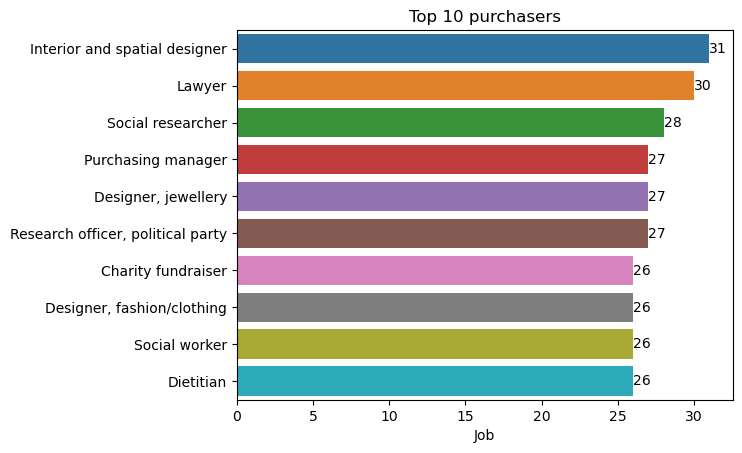

In [39]:
a=df["Job"].value_counts().sort_values(ascending=False)
a=a.head(10)
a
axis=sns.barplot(x=a,y=a.index)
axis.bar_label(axis.containers[0])
plt.title("Top 10 purchasers")
plt.show

# Time of purchase preferred by consumers:

In [40]:
b=df['AM or PM'].value_counts()
b

PM    5068
AM    4932
Name: AM or PM, dtype: int64

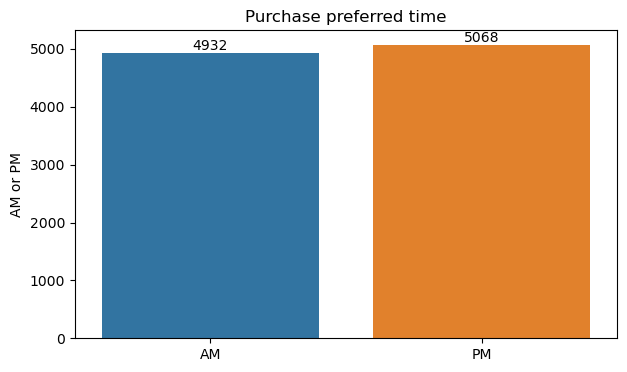

In [41]:
plt.figure(figsize=(7,4))
order=['AM','PM']
c=sns.barplot(y=b, x=b.index,order=order)
c.bar_label(c.containers[0])
plt.title("Purchase preferred time")
plt.show()

# Top languages spoken by consumers:

In [42]:
k=df["Language"].value_counts()
k

de    1155
ru    1155
el    1137
pt    1118
en    1098
fr    1097
es    1095
it    1086
zh    1059
Name: Language, dtype: int64

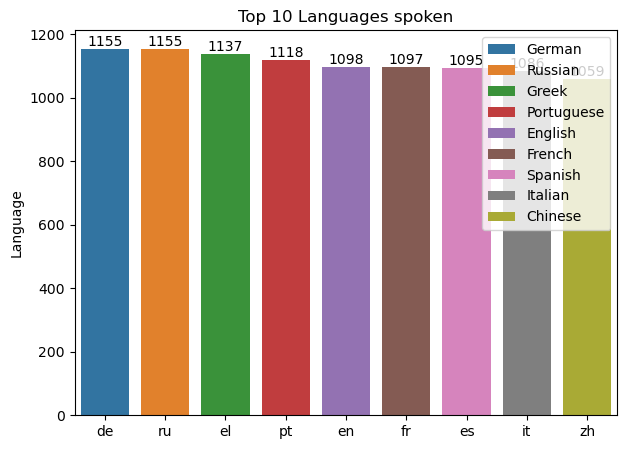

In [43]:
plt.figure(figsize=(7,5))
label1=np.array(["German","Russian","Greek","Portuguese","English","French","Spanish","Italian","Chinese"])
axis=sns.barplot(y=k,x=k.index,label=label1)
axis.bar_label(axis.containers[0])
plt.legend()
plt.title("Top 10 Languages spoken")
plt.show()

# Count of top different types of engineers that make purchases

In [44]:
#df that only has "engineers" in its job column
df1

,Address,Lot,AM or PM,Browser Info,Company,Credit Card,CC Exp Date,CC Security Code,CC Provider,Email,Job,IP Address,Language,Purchase Price
1,"9374 Jasmine Spurs Suite 508\nSouth John, TN 8...",28 rn,PM,Opera/8.93.(Windows 98; Win 9x 4.90; en-US) Pr...,"Fletcher, Richards and Whitaker",3337758169645356,11/18,561,Mastercard,anthony41@reed.com,Drilling engineer,15.160.41.51,fr,70.73
3,"7780 Julia Fords\nNew Stacy, WA 45798",36 vm,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_0 ...,"Williams, Marshall and Buchanan",6011578504430710,02/24,384,Discover,brent16@olson-robinson.info,Drilling engineer,30.250.74.19,es,78.04
50,"41159 Michael Centers\nAdamsfort, RI 37108-6674",46 Ce,PM,Mozilla/5.0 (Windows 98; Win 9x 4.90; sl-SI; r...,"Wright, Williams and Mendez",4008586485908075,05/19,945,JCB 16 digit,susanvalentine@obrien.org,Mechanical engineer,213.203.143.215,de,36.85
55,"27635 Maureen Bypass Apt. 883\nSandraview, SD ...",59 LJ,AM,Mozilla/5.0 (iPod; U; CPU iPhone OS 3_3 like M...,Sims-Lyons,3158113629128344,09/19,857,VISA 16 digit,adkinsarthur@yahoo.com,"Engineer, broadcasting (operations)",227.235.89.210,pt,48.74
60,"7126 Katherine Squares\nPerkinsview, CO 97299-...",63 qu,AM,Opera/8.68.(X11; Linux x86_64; en-US) Presto/2...,Marshall-Fernandez,349767747049645,05/20,672,JCB 15 digit,sweeneyhannah@jones.biz,"Engineer, agricultural",197.144.142.102,de,20.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9948,"95544 Johnson Isle Suite 939\nMichaelberg, RI ...",91 bW,AM,Opera/8.36.(X11; Linux x86_64; sl-SI) Presto/2...,Fox-Peterson,4762924304307,03/17,567,Mastercard,haleybenjamin@gmail.com,Structural engineer,120.36.140.58,en,71.89
9952,"9991 Vaughn Hills\nRacheltown, PA 55409",36 KC,PM,Mozilla/5.0 (X11; Linux i686; rv:1.9.5.20) Gec...,"Ward, Smith and Castillo",6011679271321726,09/19,964,Voyager,jonesjennifer@olson.com,"Engineer, energy",116.228.12.42,es,39.63
9970,"0060 Keith Stream\nWestport, CO 47097",11 nt,PM,Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_8...,"Carpenter, Good and Hart",6011485664704662,07/19,543,Discover,rangelbrian@hotmail.com,Electrical engineer,242.8.85.205,en,17.76
9977,"02182 Keith Expressway\nEast Shannon, CT 20578...",34 RL,AM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Deleon, Jacobson and Benton",4186094003664688,06/21,397,JCB 16 digit,daltoncarter@yahoo.com,Biomedical engineer,146.238.118.2,fr,94.93


In [45]:
#created a df of "job" column from df1 to use it further
t=df1["Job"].value_counts() #984 engineers
df2=pd.DataFrame(t)

In [46]:
df2=df2.reset_index()
df2=df2.head(10)
df2

,index,Job
0,Network engineer,25
1,"Engineer, water",25
2,"Civil engineer, contracting",24
3,Automotive engineer,22
4,"Engineer, land",22
5,"Engineer, building services",21
6,Biomedical engineer,21
7,Contracting civil engineer,21
8,Petroleum engineer,21
9,Mining engineer,21


In [47]:
category_values = df1.pivot_table(columns=['Job'], aggfunc='size')
category_values=category_values.sort_values(ascending=False).head(10)
category_values

Job
Engineer, water                25
Network engineer               25
Civil engineer, contracting    24
Automotive engineer            22
Engineer, land                 22
Contracting civil engineer     21
Petroleum engineer             21
Mining engineer                21
Drilling engineer              21
Engineer, building services    21
dtype: int64

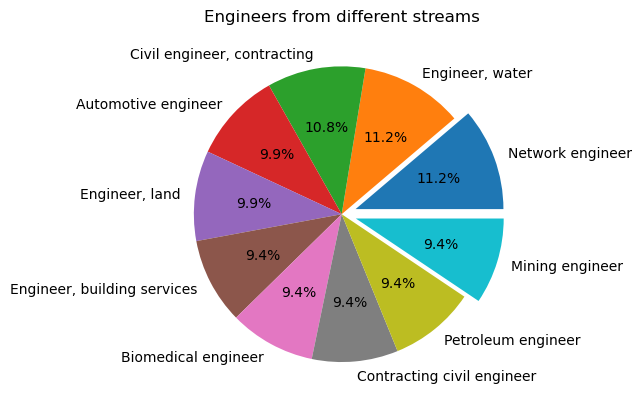

In [48]:
plt.pie(category_values, labels=df2["index"], explode=[0.1,0,0,0,0,0,0,0,0,0.1], autopct="%2.1f%%")
my_circle=plt.Circle( (0,2), 0.6, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.title("Engineers from different streams")
plt.show()

# Different CC service providers and purchases made via them

In [49]:
df

,Address,Lot,AM or PM,Browser Info,Company,Credit Card,CC Exp Date,CC Security Code,CC Provider,Email,Job,IP Address,Language,Purchase Price,temp
0,"16629 Pace Camp Apt. 448\nAlexisborough, NE 77...",46 in,PM,Opera/9.56.(X11; Linux x86_64; sl-SI) Presto/2...,Martinez-Herman,6011929061123406,02/20,900,JCB 16 digit,pdunlap@yahoo.com,"Scientist, product/process development",149.146.147.205,el,98.14,yahoo.com
1,"9374 Jasmine Spurs Suite 508\nSouth John, TN 8...",28 rn,PM,Opera/8.93.(Windows 98; Win 9x 4.90; en-US) Pr...,"Fletcher, Richards and Whitaker",3337758169645356,11/18,561,Mastercard,anthony41@reed.com,Drilling engineer,15.160.41.51,fr,70.73,reed.com
2,Unit 0065 Box 5052\nDPO AP 27450,94 vE,PM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Simpson, Williams and Pham",675957666125,08/19,699,JCB 16 digit,amymiller@morales-harrison.com,Customer service manager,132.207.160.22,de,0.95,morales-harrison.com
3,"7780 Julia Fords\nNew Stacy, WA 45798",36 vm,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_0 ...,"Williams, Marshall and Buchanan",6011578504430710,02/24,384,Discover,brent16@olson-robinson.info,Drilling engineer,30.250.74.19,es,78.04,olson-robinson.info
4,"23012 Munoz Drive Suite 337\nNew Cynthia, TX 5...",20 IE,AM,Opera/9.58.(X11; Linux x86_64; it-IT) Presto/2...,"Brown, Watson and Andrews",6011456623207998,10/25,678,Diners Club / Carte Blanche,christopherwright@gmail.com,Fine artist,24.140.33.94,es,77.82,gmail.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,"966 Castaneda Locks\nWest Juliafurt, CO 96415",92 XI,PM,Mozilla/5.0 (Windows NT 5.1) AppleWebKit/5352 ...,Randall-Sloan,342945015358701,03/22,838,JCB 15 digit,iscott@wade-garner.com,Printmaker,29.73.197.114,it,82.21,wade-garner.com
9996,"832 Curtis Dam Suite 785\nNorth Edwardburgh, T...",41 JY,AM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Hale, Collins and Wilson",210033169205009,07/25,207,JCB 16 digit,mary85@hotmail.com,Energy engineer,121.133.168.51,pt,25.63,hotmail.com
9997,Unit 4434 Box 6343\nDPO AE 28026-0283,74 Zh,AM,Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_7...,Anderson Ltd,6011539787356311,05/21,1,VISA 16 digit,tyler16@gmail.com,Veterinary surgeon,156.210.0.254,el,83.98,gmail.com
9998,"0096 English Rest\nRoystad, IA 12457",74 cL,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_8;...,Cook Inc,180003348082930,11/17,987,American Express,elizabethmoore@reid.net,Local government officer,55.78.26.143,es,38.84,reid.net


In [50]:
df["CC Provider"].value_counts()

JCB 16 digit                   1716
VISA 16 digit                  1715
JCB 15 digit                    868
American Express                849
Maestro                         846
Voyager                         829
Discover                        817
Mastercard                      816
VISA 13 digit                   777
Diners Club / Carte Blanche     767
Name: CC Provider, dtype: int64

In [51]:
var=df["CC Provider"].value_counts()
df3=pd.DataFrame(var)
df3

,CC Provider
JCB 16 digit,1716
VISA 16 digit,1715
JCB 15 digit,868
American Express,849
Maestro,846
Voyager,829
Discover,817
Mastercard,816
VISA 13 digit,777
Diners Club / Carte Blanche,767


In [52]:
df3=df3.reset_index()
df3

,index,CC Provider
0,JCB 16 digit,1716
1,VISA 16 digit,1715
2,JCB 15 digit,868
3,American Express,849
4,Maestro,846
5,Voyager,829
6,Discover,817
7,Mastercard,816
8,VISA 13 digit,777
9,Diners Club / Carte Blanche,767


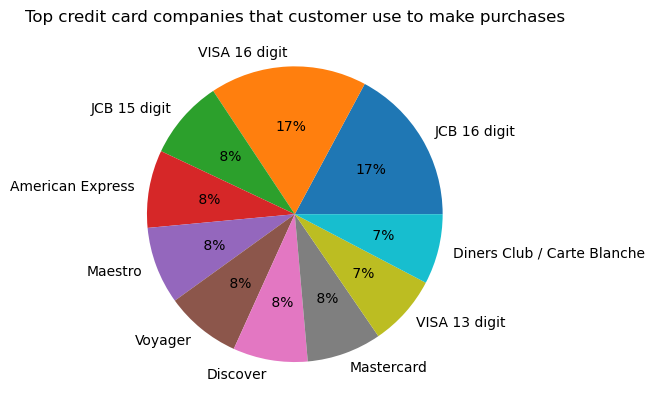

In [53]:
cat_val=var
cat_name=df3['index']
plt.pie(cat_val,labels=cat_name,autopct="%2.1d%%")
circ=plt.Circle( (0,2), 0.6, color='white')
p=plt.gcf()
p.gca().add_artist(circ)
plt.title("Top credit card companies that customer use to make purchases")
plt.show()

# Conclusion:
1. Most customers are either Interior/saptial designers or lawyers.
2. Most purchases were done by customers who speak German and Russian.
3. Maximum purchases were observed in second half of a normal day.
4. "Hotmail" online e-mail service was seen as most used mail service by the consumers.
5. JCB and VISA bagged the most used credit card service providers in purchases made by the clients.